In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shebrahimi/financial-distress/Financial Distress.csv


# Importando Bibliotecas

In [32]:
import numpy as np
import pandas as pd

# Guarda o csv num dataframe

In [33]:
df = pd.read_csv('/kaggle/input/datasets/shebrahimi/financial-distress/Financial Distress.csv')

# Mostra tamanho da tabela, cinco primeiras linhas, nome de cada coluna, quantos valores não-nulos ela tem, e o tipo de dado

In [34]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 86 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company             3672 non-null   int64  
 1   Time                3672 non-null   int64  
 2   Financial Distress  3672 non-null   float64
 3   x1                  3672 non-null   float64
 4   x2                  3672 non-null   float64
 5   x3                  3672 non-null   float64
 6   x4                  3672 non-null   float64
 7   x5                  3672 non-null   float64
 8   x6                  3672 non-null   float64
 9   x7                  3672 non-null   float64
 10  x8                  3672 non-null   float64
 11  x9                  3672 non-null   float64
 12  x10                 3672 non-null   float64
 13  x11                 3672 non-null   float64
 14  x12                 3672 non-null   float64
 15  x13                 3672 non-null   float64
 16  x14   

# Verificando se há valores nulos nas colunas

In [35]:
df.isnull().sum().sum()

np.int64(0)

# Verificando quantos valores unicos existem em cada coluna de tipo int, para identificar possiveis valores categoricos

In [36]:
for col in ['x80', 'x82', 'x83']:
    print(col, df[col].nunique())

x80 37
x82 49
x83 71


# Coluna que identifica dificuldade financeira

In [37]:

df['target'] = (df['Financial Distress'] < -0.50).astype(int)

# Conta quantas linhas foram identificadas como dificuldade financeira

In [38]:
df['target'].value_counts(normalize=True)

target
0    0.962963
1    0.037037
Name: proportion, dtype: float64

# Definindo coluna x80 como categorica

In [39]:
df = pd.get_dummies(df, columns=['x80'], drop_first=True)



# Definindo X e Y (features e target)

In [40]:
X = df.drop(columns=['Company', 'Time', 'Financial Distress', 'target'])
y = df['target']

# Treino e teste (70-30)
Usa groups=df['Company'], inves de split aleatorio pois a mesma empresa aparece varias vezes

In [41]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['Company']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Normaliza escala

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treina o modelo

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

svc = SVC(class_weight='balanced', random_state=42)

grid = GridSearchCV(svc, param_grid, scoring='f1', cv=5)
grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", grid.best_params_)
modelo = grid.best_estimator_

Melhores parâmetros: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


# Previsao

In [44]:
y_pred = modelo.predict(X_test_scaled)

# Avalia desempenho com f-score

In [45]:
from sklearn.metrics import f1_score, classification_report

print("F1-score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1-score: 0.32558139534883723
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1124
           1       0.21      0.70      0.33        30

    accuracy                           0.92      1154
   macro avg       0.60      0.82      0.64      1154
weighted avg       0.97      0.92      0.94      1154



# Matriz de Confusão

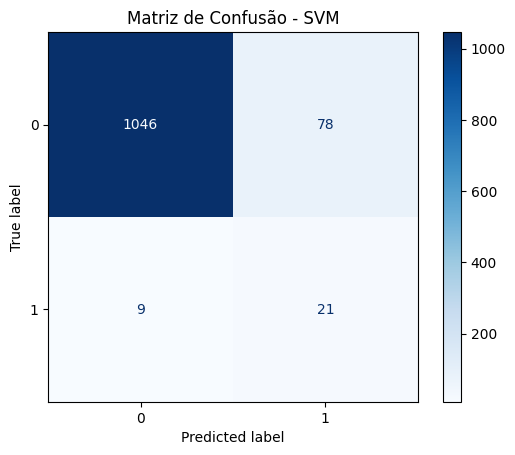

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Matriz de Confusão - SVM')
plt.show()